In [1]:
import pandas as pd
import numpy as np

from google.colab import files

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report

In [2]:
uploaded = files.upload()

Saving Credit_Risk_Assessment_Dataset (1).xlsx to Credit_Risk_Assessment_Dataset (1).xlsx


In [3]:
df = pd.read_excel("Credit_Risk_Assessment_Dataset (1).xlsx")

In [4]:
df.head()

,Applicant_ID,Income,Credit_History_Score,Employment_Status,Loan_Amount,Risk_Label
0,1,60000,750,Employed,200000,Low Risk
1,2,25000,450,Unemployed,300000,High Risk
2,3,80000,820,Employed,150000,Low Risk
3,4,30000,500,Unemployed,250000,High Risk
4,5,70000,780,Employed,180000,Low Risk


In [22]:
import matplotlib.pyplot as plt

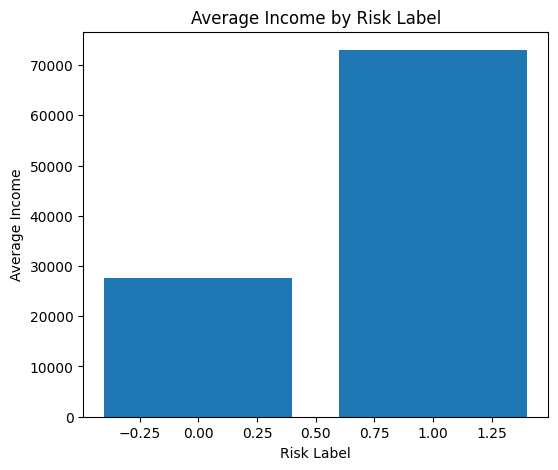

In [23]:
income = df.groupby("Risk_Label")["Income"].mean()

plt.figure(figsize=(6,5))
plt.bar(income.index, income.values)

plt.title("Average Income by Risk Label")
plt.xlabel("Risk Label")
plt.ylabel("Average Income")

plt.show()

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10 entries, 0 to 9
Data columns (total 6 columns):
 #   Column                Non-Null Count  Dtype 
---  ------                --------------  ----- 
 0   Applicant_ID          10 non-null     int64 
 1   Income                10 non-null     int64 
 2   Credit_History_Score  10 non-null     int64 
 3   Employment_Status     10 non-null     object
 4   Loan_Amount           10 non-null     int64 
 5   Risk_Label            10 non-null     object
dtypes: int64(4), object(2)
memory usage: 612.0+ bytes


In [6]:
df.describe()

,Applicant_ID,Income,Credit_History_Score,Loan_Amount
count,10.00000,10.000000,10.000000,10.000000
mean,5.50000,50300.000000,627.000000,231000.000000
std,3.02765,25512.741915,171.985141,74004.504367
min,1.00000,20000.000000,400.000000,120000.000000
25%,3.25000,28500.000000,485.000000,182500.000000
50%,5.50000,47500.000000,620.000000,225000.000000
75%,7.75000,68750.000000,772.500000,287500.000000
max,10.00000,90000.000000,850.000000,350000.000000


In [7]:
df.isnull().sum()

,0
Applicant_ID,0
Income,0
Credit_History_Score,0
Employment_Status,0
Loan_Amount,0
Risk_Label,0


In [8]:
df.drop_duplicates(inplace=True)

In [9]:
encoder = LabelEncoder()

df["Employment_Status"] = encoder.fit_transform(df["Employment_Status"])

In [10]:
df["Risk_Label"] = encoder.fit_transform(df["Risk_Label"])

In [11]:
df.head()

,Applicant_ID,Income,Credit_History_Score,Employment_Status,Loan_Amount,Risk_Label
0,1,60000,750,0,200000,1
1,2,25000,450,1,300000,0
2,3,80000,820,0,150000,1
3,4,30000,500,1,250000,0
4,5,70000,780,0,180000,1


In [12]:
X = df.drop(["Applicant_ID", "Risk_Label"], axis=1)

y = df["Risk_Label"]

In [13]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

In [14]:
model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

In [15]:
model.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

In [16]:
y_pred = model.predict(X_test)

In [17]:
accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)

Accuracy: 1.0


In [18]:
cm = confusion_matrix(y_test, y_pred)

print(cm)


[[1 0]
 [0 1]]


In [19]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00         1
           1       1.00      1.00      1.00         1

    accuracy                           1.00         2
   macro avg       1.00      1.00      1.00         2
weighted avg       1.00      1.00      1.00         2



In [20]:
new_customer = np.array([[50000,700,0,250000]])

prediction = model.predict(new_customer)

print(prediction)

[1]


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


In [21]:
if prediction[0] == 0:
    print("High Risk")
else:
    print("Low Risk")

Low Risk
